<div>
Olá, Chau!

Meu nome é Luiz. Fico feliz em revisar seu projeto. Ao longo do texto farei algumas observações sobre melhorias no código e também farei comentários sobre suas percepções sobre o assunto. Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender o meu feedback no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítico, mas que pode ser corrigido para melhoria geral no seu código/análise.
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser arrumado, caso contrário seu projeto **não** será aceito.
</div>

Você pode interagir comigo através dessa célula:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

<div class="alert alert-block alert-success">
<b> Comentário geral do revisor</b> <a class="tocSkip"></a>

Obrigado por enviar o seu projeto e pelo esforço de chegar até aqui. O seu projeto possui alguns pontos bem interessantes, dos quais eu destaco:
    
- Código bem simples e estruturado 
- Comentários sucintos e bem objetivos
- Análises bem detalhadas em cada etapa do projeto
- Boas habilidades de manipulação de dados
    
<br>
Espero que as sugestões sejam relevantes para projetos futuros. Te desejo uma jornada de muito sucesso e aprendizado. 
        
<br>   
    
Qualquer dúvida, pode contar comigo.   
    
<br>  
    
**Até breve!**

</div>

### Iniciação
1. Importando bibliotecas.
2. Carregando e verificando os arquivos.
3. Pre-processamento dos dados.
4. Formando para tipo time.
5. Verificando valores nulos e duplicados.
6. Adicionando coluna de datas.


In [122]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
import math


In [55]:
#Leitura e analise de dados

In [56]:
data = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- O conjunto de dados foi carregado corretamente
- O import das bibliotecas foi feito de forma correta e em uma célula separada
</div>

In [57]:
data.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [58]:
data.describe()

,DeviceIDHash,EventTimestamp,ExpId
count,2.441260e+05,2.441260e+05,244126.000000
mean,4.627568e+18,1.564914e+09,247.022296
std,2.642425e+18,1.771343e+05,0.824434
min,6.888747e+15,1.564030e+09,246.000000
25%,2.372212e+18,1.564757e+09,246.000000
50%,4.623192e+18,1.564919e+09,247.000000
75%,6.932517e+18,1.565075e+09,248.000000
max,9.222603e+18,1.565213e+09,248.000000


In [59]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


In [60]:
# Formatação de nomes e colunas.

In [61]:
data = data.rename(columns={'EventName':'event', 'DeviceIDHash': 'id', 'EventTimestamp': 'time', 'ExpId': 'group'})

In [62]:
data['event'] = data['event'].str.lower()
data['time'] = pd.to_datetime(data['time'], unit='s')

In [63]:
# Verificação e correção de valores nulos/duplicados

In [64]:
data.isnull().sum()

event    0
id       0
time     0
group    0
dtype: int64

In [65]:
data.duplicated().sum()

413

In [66]:
data = data.drop_duplicates()

In [67]:
# Adicionando coluna para datas

In [68]:
data['date'] = data['time'].dt.date

In [69]:
data.head()

,event,id,time,group,date
0,mainscreenappear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,mainscreenappear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,paymentscreensuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,cartscreenappear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,paymentscreensuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25


### Calculando quantidade de eventos nos registros

In [70]:
events_count = data['event'].count()
events_count

243713

In [71]:
nunique_events = data['event'].nunique()
nunique_events

5

In [72]:
# Temos um total de 244126 eventos registrados para 5 tipos de eventos no registro.

### Calculando quantidade de usuários nos registros

In [73]:
id_nunique = data['id'].nunique()

In [74]:
print(f"O total de usuários únicos nos registros é : {id_nunique}")

O total de usuários únicos nos registros é : 7551


### Número médio de eventos por usuários

In [75]:
id_events_count = events_count / id_nunique
print(f"Número médio de eventos por usuário é de : {id_events_count}")

Número médio de eventos por usuário é de : 32.27559263673685


# Calculando o período de tempo que os dados cobrem.

In [76]:
# Criando um histograma por data e hora.

In [77]:
data_min = data['time'].min()
data_max = data['time'].max()
print(f"Periodo em que os dados cobrem é de {data_min} a {data_max}")

Periodo em que os dados cobrem é de 2019-07-25 04:43:36 a 2019-08-07 21:15:17


<AxesSubplot:>

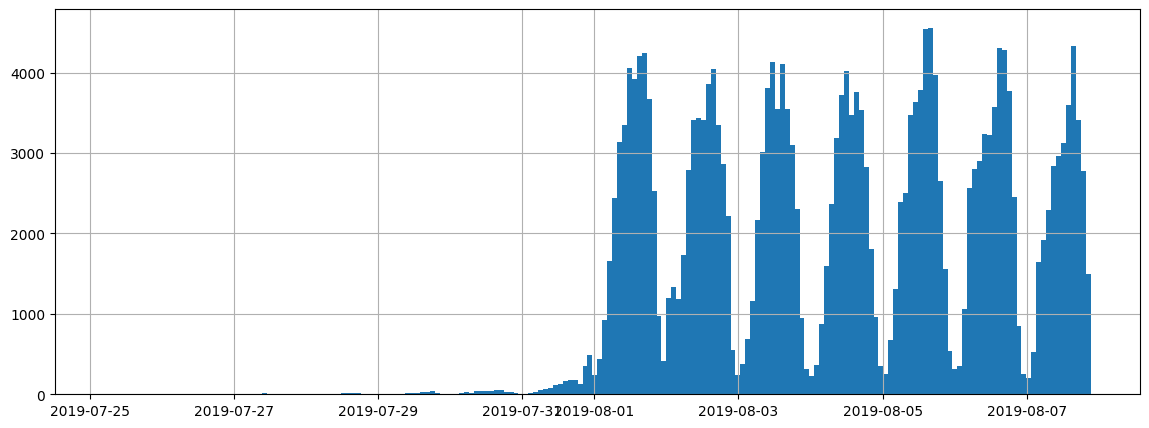

In [78]:
data['time'].hist(figsize=(14, 5), bins=200)

In [79]:
# Do começo dos dados em 29-07-25 até a data 2019-08-01 tivemos menos de 500 acessos, pelo poucos dados disponiveis no periodo pode ser entendido como periodo de teste da plataforma.
# Podemos considerar os dados reais apartir da data 01-08-2019.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
  
As estatísticas dos usuários foram analisadas. Bom trabalho plotando o gráfico acima!
</div>

### Verificando os dados antes da data 2019-08-01

In [80]:
data

,event,id,time,group,date
0,mainscreenappear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,mainscreenappear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,paymentscreensuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,cartscreenappear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,paymentscreensuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25
...,...,...,...,...,...
244121,mainscreenappear,4599628364049201812,2019-08-07 21:12:25,247,2019-08-07
244122,mainscreenappear,5849806612437486590,2019-08-07 21:13:59,246,2019-08-07
244123,mainscreenappear,5746969938801999050,2019-08-07 21:14:43,246,2019-08-07
244124,mainscreenappear,5746969938801999050,2019-08-07 21:14:58,246,2019-08-07


In [81]:
full_data = data['event'].value_counts()

In [82]:
print(full_data)

mainscreenappear           119101
offersscreenappear          46808
cartscreenappear            42668
paymentscreensuccessful     34118
tutorial                     1018
Name: event, dtype: int64


In [83]:
filtered_values = data[data['time'] < '2019-08-01'].groupby('id', as_index=False).agg({'event': pd.Series.nunique})

In [84]:
filtered_values

,id,event
0,19151588103329050,1
1,32131536909829030,1
2,33176906322804559,1
3,33589551945846495,1
4,38880205595577265,1
...,...,...
1446,9182444363400946277,1
1447,9192059464363071054,3
1448,9194161737535459139,1
1449,9216369613838971606,1


In [85]:
# Poucos dados serão perdidos na filtragem de datas.

In [86]:
#Realizando a filtragem de dados e removendo todos antes da data 2019-08-01.

In [87]:
filtered_data = data[~data['id'].isin(filtered_values)]

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- A quantidade de eventos descartados após o filtro foi analisada corretamente. Bom trabalho calculando o percentual de perda de usuários!
</div>

### Formando grupos e conferindo grupos

In [88]:
filtered_data

,event,id,time,group,date
0,mainscreenappear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,mainscreenappear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
2,paymentscreensuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,cartscreenappear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,paymentscreensuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25
...,...,...,...,...,...
244121,mainscreenappear,4599628364049201812,2019-08-07 21:12:25,247,2019-08-07
244122,mainscreenappear,5849806612437486590,2019-08-07 21:13:59,246,2019-08-07
244123,mainscreenappear,5746969938801999050,2019-08-07 21:14:43,246,2019-08-07
244124,mainscreenappear,5746969938801999050,2019-08-07 21:14:58,246,2019-08-07


In [89]:
group_246 = filtered_data[filtered_data['group'] == 246]
group_247 = filtered_data[filtered_data['group'] == 247]
group_248 = filtered_data[filtered_data['group'] == 248]

In [90]:
group_246

,event,id,time,group,date
0,mainscreenappear,4575588528974610257,2019-07-25 04:43:36,246,2019-07-25
1,mainscreenappear,7416695313311560658,2019-07-25 11:11:42,246,2019-07-25
6,offersscreenappear,8351860793733343758,2019-07-25 14:50:42,246,2019-07-25
7,mainscreenappear,5682100281902512875,2019-07-25 20:14:37,246,2019-07-25
9,mainscreenappear,5407636962369102641,2019-07-26 03:35:12,246,2019-07-26
...,...,...,...,...,...
244120,mainscreenappear,5746969938801999050,2019-08-07 21:12:11,246,2019-08-07
244122,mainscreenappear,5849806612437486590,2019-08-07 21:13:59,246,2019-08-07
244123,mainscreenappear,5746969938801999050,2019-08-07 21:14:43,246,2019-08-07
244124,mainscreenappear,5746969938801999050,2019-08-07 21:14:58,246,2019-08-07


In [91]:
group_247

,event,id,time,group,date
8,mainscreenappear,1850981295691852772,2019-07-25 20:31:42,247,2019-07-25
10,mainscreenappear,948465712512390382,2019-07-26 05:33:34,247,2019-07-26
13,mainscreenappear,2140904690380565988,2019-07-26 07:22:12,247,2019-07-26
16,mainscreenappear,5839517684026830712,2019-07-26 11:43:41,247,2019-07-26
18,cartscreenappear,2575393697599976818,2019-07-26 13:49:05,247,2019-07-26
...,...,...,...,...,...
244088,mainscreenappear,2300292234025330845,2019-08-07 21:05:37,247,2019-08-07
244089,offersscreenappear,2300292234025330845,2019-08-07 21:05:43,247,2019-08-07
244090,offersscreenappear,2300292234025330845,2019-08-07 21:05:54,247,2019-08-07
244091,mainscreenappear,2300292234025330845,2019-08-07 21:05:57,247,2019-08-07


In [92]:
group_248

,event,id,time,group,date
2,paymentscreensuccessful,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
3,cartscreenappear,3518123091307005509,2019-07-25 11:28:47,248,2019-07-25
4,paymentscreensuccessful,6217807653094995999,2019-07-25 11:48:42,248,2019-07-25
5,cartscreenappear,6217807653094995999,2019-07-25 11:48:43,248,2019-07-25
11,mainscreenappear,2547684315586332355,2019-07-26 06:50:26,248,2019-07-26
...,...,...,...,...,...
244082,mainscreenappear,8249271441488197538,2019-08-07 21:03:33,248,2019-08-07
244084,offersscreenappear,8249271441488197538,2019-08-07 21:03:43,248,2019-08-07
244109,mainscreenappear,5317814261427487562,2019-08-07 21:09:22,248,2019-08-07
244110,offersscreenappear,5317814261427487562,2019-08-07 21:09:27,248,2019-08-07


In [93]:
# Temos registros suficientes para cada grupo.

# Estudo de funil de eventos

##### Confirmando eventos e sua frequência para cada grupo

In [94]:
group_246['event'].value_counts()

mainscreenappear           38249
offersscreenappear         14904
cartscreenappear           14798
paymentscreensuccessful    11912
tutorial                     318
Name: event, dtype: int64

In [95]:
group_247['event'].value_counts()

mainscreenappear           39677
offersscreenappear         15341
cartscreenappear           12548
paymentscreensuccessful    10039
tutorial                     345
Name: event, dtype: int64

In [96]:
group_248['event'].value_counts()

mainscreenappear           41175
offersscreenappear         16563
cartscreenappear           15322
paymentscreensuccessful    12167
tutorial                     355
Name: event, dtype: int64

### Estudo do funil de eventos

In [97]:
total_users = filtered_data['id'].nunique()
event_users = filtered_data.groupby('event')['id'].nunique().reset_index()
event_users = pd.DataFrame(event_users)
event_users = event_users.rename(columns={'id': 'uniq_users'})

In [98]:
print(f"Usuários únicos: {total_users}")

Usuários únicos: 7551


In [99]:
event_users['proporcoes'] = event_users['uniq_users'] / total_users 

In [100]:
print(event_users.sort_values(by = 'uniq_users', ascending=False))

                     event  uniq_users  proporcoes
1         mainscreenappear        7439    0.985168
2       offersscreenappear        4613    0.610912
0         cartscreenappear        3749    0.496491
3  paymentscreensuccessful        3547    0.469739
4                 tutorial         847    0.112171


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>
    
- A proporção de usuários por etapa do funil foi analisada
- A ordem das etapas foi calculada!
</div>

In [101]:
# Todos os eventos parecem fazer parte de uma sessão de compras seguindo a sequência de funil, apenas os dados de tutorial não se encaixam no padrão.
# Podemos notar uma perda de cerca de 1,5% de usuários antes de entrar na mainscreean.

In [102]:
# A fase com maior perca de usuários seria entre A e B, 37% dos clientes perdidos.
# Quase 47% dos usuarios fazem todo o percurso da pagina principal, até a tela de pagamento com sucesso.

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- A conversão dos usuários por etapa do funil foi analisada
- O percentual de usuários que percorrem todo o caminho foi calculado
- O número de usuários por grupo foi analisado
</div>

### Estude os resultados do experimento

In [103]:
user_group_246 = group_246['id'].nunique()
user_group_247 = group_247['id'].nunique()
user_group_248 = group_248['id'].nunique()

In [104]:
print(f"Número de usuários no grupo 246 é de :{user_group_246}")
print(f"Número de usuários no grupo 247 é de :{user_group_247}")
print(f"Número de usuários no grupo 248 é de :{user_group_248}")

Número de usuários no grupo 246 é de :2489
Número de usuários no grupo 247 é de :2520
Número de usuários no grupo 248 é de :2542


### Teste A/A, verificando se há diferença estatistica entre as amostras dos grupos 246 e 247

In [105]:

events_246 = group_246.groupby('event')['id'].nunique().reset_index()
events_246 = pd.DataFrame(events_246)
events_246 = events_246.rename(columns={'id' : 'uniq_id'})
events_246['proporcoes'] = events_246['uniq_id'] / user_group_246
print(events_246.sort_values(by = 'uniq_id', ascending=False))


                     event  uniq_id  proporcoes
1         mainscreenappear     2456    0.986742
2       offersscreenappear     1545    0.620731
0         cartscreenappear     1270    0.510245
3  paymentscreensuccessful     1202    0.482925
4                 tutorial      279    0.112093


In [106]:

events_247 = group_247.groupby('event')['id'].nunique().reset_index()
events_247 = pd.DataFrame(events_247)
events_247 = events_247.rename(columns={'id' : 'uniq_id'})
events_247['proporcoes'] = events_247['uniq_id'] / user_group_247
print(events_247.sort_values(by = 'uniq_id', ascending=False))



                     event  uniq_id  proporcoes
1         mainscreenappear     2482    0.984921
2       offersscreenappear     1530    0.607143
0         cartscreenappear     1240    0.492063
3  paymentscreensuccessful     1160    0.460317
4                 tutorial      286    0.113492


In [107]:
events_248 = group_248.groupby('event')['id'].nunique().reset_index()
events_248 = pd.DataFrame(events_248)
events_248 = events_248.rename(columns={'id' : 'uniq_id'})
events_248['proporcoes'] = events_248['uniq_id'] / user_group_248
print(events_248.sort_values(by = 'uniq_id', ascending=False))



                     event  uniq_id  proporcoes
1         mainscreenappear     2501    0.983871
2       offersscreenappear     1538    0.605035
0         cartscreenappear     1239    0.487411
3  paymentscreensuccessful     1185    0.466168
4                 tutorial      282    0.110936


In [75]:
# Classificando amostras para teste A/A

In [51]:
count = [1202, 1160]
nobs = [2456, 2482]

stat, pval = proportions_ztest(count, nobs)

print(f"Estatística z: {stat:.3f}")
print(f"P-value: {pval:.4f}")

if pval < 0.05:
    print("Diferença estatisticamente significativa.")
else:
    print("Não há diferença estatisticamente significativa")


Estatística z: 1.551
P-value: 0.1209
Não há diferença estatisticamente significativa


In [52]:
# Não temos diferença estatisticamente significativa entre os grupos no teste A/A

In [108]:
print(f"Número de usuários no grupo 246 é de :{user_group_246}")
print(f"Número de usuários no grupo 247 é de :{user_group_247}")
print(f"Número de usuários no grupo 248 é de :{user_group_248}")

Número de usuários no grupo 246 é de :2489
Número de usuários no grupo 247 é de :2520
Número de usuários no grupo 248 é de :2542


<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

- O teste foi executado corretamente
- As estatísticas e `p-valor` foram calculados
</div>